In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import torch
from sentence_transformers import SentenceTransformer

print(np.__version__)
print(torch.__version__)

2.0.2
2.10.0+cpu


In [3]:
import pandas as pd
path = "/content/drive/MyDrive/CaseStudyDataPremiseHealth.xlsx"

file = pd.read_excel(path, sheet_name = ["Medical claims data", "member_data_with_surveys"])

df_claims = file["Medical claims data"]
df_surveys = file["member_data_with_surveys"]

In [4]:
df_claims.head()

,Member ID,Claim Number,Service Date,Paid Date,Place of Service Description,Speciality,Provider Specialty,Paid Amount,Allowed Amount,Primary Diagnosis Desc,Procedure Description,CPT4,Vendor Name,Procedure,Procedure Grouper Desc,Procedure Sub-Grouper Desc,Diagnosis Grouper 1 Desc,Diagnosis Super-Grouper 1 Desc
0,1.0,H19343218281891900000000,2019-11-13,2019-12-13,Outpatient Hospital,A1,DWSC1-12,159.377500,159.377500,"Edema, Unspecified",Hydrate Iv Infusion Add-On,96361,Blue Cross,96361,Other Procedures,Minor Procedures - Other,Constitutional Symptoms,Miscellaneous
1,1.0,H19343218281891900000000,2019-11-13,2019-12-13,Outpatient Hospital,A1,DWSC1-12,14.223654,14.223654,"Edema, Unspecified",Routine Venipuncture,36415,Blue Cross,36415,Laboratory,Lab - Blood Tests,Constitutional Symptoms,Miscellaneous
2,1.0,H19324218270523690000000,2019-11-13,2019-11-22,Inpatient Hospital,A1,DWSC1-12,56.709615,56.709615,Portal Hypertension,Lab/Other,BK,Blue Cross,R309,Laboratory,Lab - Other,Liver Diseases,Gastrointestinal Disorders
3,1.0,H19323218269729840000000,2019-11-15,2019-11-22,Inpatient Hospital,AW,DWSC1-3,45.346346,45.346346,Other Ascites,Echo Exam Of Abdomen,76705,Blue Cross,76705,Imaging/Radiology,Echography/Ultrasonography - Abdomen/Pelvis,Abdominal Disorders,Gastrointestinal Disorders
4,1.0,H19343218281960710000000,2019-11-13,2019-12-13,Emergency Room - Hospital,CS,DWSC1-12,186.280769,186.280769,"Edema, Unspecified",Emergency Dept Visit,99285,Blue Cross,99285,Emergency Room,Emergency Room,Constitutional Symptoms,Miscellaneous


In [5]:
df_surveys.head()

,Member ID,Age,Member Gender,Prospective Risk,Concurrent Risk,# of Chronic Conditions,ADHD,Asthma,Blood Disorders,Cancer,...,Chronic Respiratory Failure,Depression,Diabetes,ESRD,Eating Disorders,HIV/AIDS,Hyperlipidemia,Hypertension,Lower Back Pain,Patient Survey Response
0,1,84,F,23.72,13.39,7,No,No,No,Yes,...,No,Yes,Yes,No,No,No,Yes,Yes,No,NaN
1,2,62,F,1.76,0.75,4,No,No,No,No,...,No,No,No,No,No,No,No,Yes,Yes,I don't feel like my doctor listens to my conc...
2,3,73,F,0.85,0.42,2,No,No,No,No,...,No,No,No,No,No,No,No,No,Yes,My provider is knowledgeable and compassionate...
3,4,44,M,0.82,0.36,3,No,No,No,No,...,No,Yes,No,No,No,No,No,Yes,Yes,My provider is knowledgeable and compassionate...
4,5,44,F,0.13,0,0,No,No,No,No,...,No,No,No,No,No,No,No,No,No,It's fine. Sometimes I wait a while but the ca...


In [6]:
df_surveys_without_na = df_surveys.dropna(subset="Patient Survey Response")

# Sentiment Analysis:

The section below takes a pre-set list of positive and negative words, encodes them, and finds the centroid of each set of words in the embedding space. For each patient feedback review, we encode the review and measure cosine similarity between the feedback and both the positive and negative sets of words, and calculate the difference to get an overall sentiment score.

In [7]:
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans

model = SentenceTransformer("all-MiniLM-L6-V2")
embeddings = model.encode(df_surveys_without_na['Patient Survey Response'].tolist())

pos_words = ["good", "great", "excellent", "love", "amazing", "positive", "satisfied", "compassionate", "happy"]
neg_words = ["bad", "terrible", "awful", "hate", "horrible", "negative", "unsatisfied", "misdiagnosed", "unacceptable", "poor", "overwhelming"]

pos_center = model.encode(pos_words).mean(axis=0)
neg_center = model.encode(neg_words).mean(axis=0)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [8]:
from numpy import dot
from numpy.linalg import norm

def cosine(a, b):
    return dot(a, b) / (norm(a) * norm(b))

scores = []

for vec in embeddings:
    pos_sim = cosine(vec, pos_center)
    neg_sim = cosine(vec, neg_center)

    score = pos_sim - neg_sim
    scores.append(score)

df_surveys_without_na["sentiment_score"] = scores

/tmp/ipykernel_11079/3383595180.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_surveys_without_na["sentiment_score"] = scores


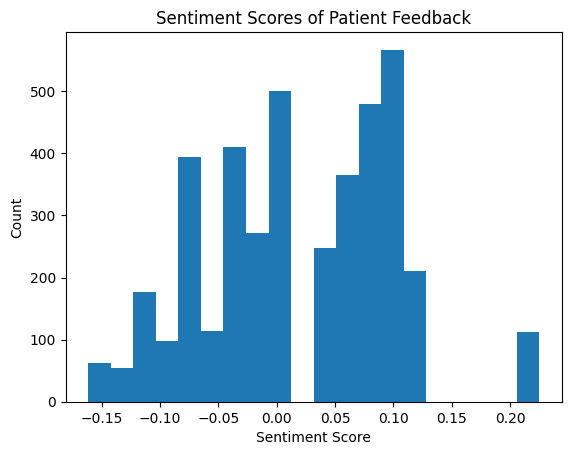

In [9]:
import matplotlib.pyplot as plt

plt.hist(df_surveys_without_na["sentiment_score"], bins=20)
plt.title("Sentiment Scores of Patient Feedback")
plt.xlabel("Sentiment Score")
plt.ylabel("Count")
plt.show()

In [10]:
df_surveys_without_na["Patient Survey Response"] = df_surveys_without_na["Patient Survey Response"].str.strip()

df_surveys_without_na["sentiment_score_rounded"] = df_surveys_without_na["sentiment_score"].round(3)

grouped = (
    df_surveys_without_na.groupby(["Patient Survey Response", "sentiment_score_rounded"])
      .size()
      .reset_index(name="count")
)
sorted_grouped = grouped.sort_values(by="sentiment_score_rounded")

print("\nMost Positive (aggregated):\n")

for _, row in sorted_grouped.tail(5).iterrows():
    print(f"{row['sentiment_score_rounded']:.3f} | n={row['count']} → {row['Patient Survey Response']}")

print("Most Negative (aggregated):\n")

for _, row in sorted_grouped.head(5).iterrows():
    print(f"{row['sentiment_score_rounded']:.3f} | n={row['count']} → {row['Patient Survey Response']}")


Most Positive (aggregated):

0.104 | n=118 → My care plan makes sense and I understand my treatment goals.
0.106 | n=111 → I appreciate that my doctor takes time to answer all my questions.
0.115 | n=100 → Excellent communication from my provider. They always follow up.
0.115 | n=110 → My doctor is wonderful. I feel heard and supported every visit.
0.225 | n=112 → I'm happy with the care I receive. My medications are well managed.
Most Negative (aggregated):

-0.162 | n=63 → Communication is terrible. Left hand doesn't know what the right is doing.
-0.132 | n=55 → The billing department is a nightmare. Errors on every statement.
-0.112 | n=61 → The facility feels outdated and not very clean. Disappointed.
-0.106 | n=116 → No major complaints. Just wish they had more availability.
-0.092 | n=67 → They rushed through my appointment in under 5 minutes. Unacceptable.


/tmp/ipykernel_11079/1816005646.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_surveys_without_na["Patient Survey Response"] = df_surveys_without_na["Patient Survey Response"].str.strip()
/tmp/ipykernel_11079/1816005646.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_surveys_without_na["sentiment_score_rounded"] = df_surveys_without_na["sentiment_score"].round(3)


# Logistic Regression:

I am going to run logistic regression to determine which features (health-related conditions) are correlated with more positive or more negative feedback.

In [11]:
df_surveys_without_na["sentiment_binary"] = (df_surveys_without_na["sentiment_score"] > 0).astype(int)

/tmp/ipykernel_11079/322907530.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_surveys_without_na["sentiment_binary"] = (df_surveys_without_na["sentiment_score"] > 0).astype(int)


In [12]:
df_surveys_without_na.head()

,Member ID,Age,Member Gender,Prospective Risk,Concurrent Risk,# of Chronic Conditions,ADHD,Asthma,Blood Disorders,Cancer,...,ESRD,Eating Disorders,HIV/AIDS,Hyperlipidemia,Hypertension,Lower Back Pain,Patient Survey Response,sentiment_score,sentiment_score_rounded,sentiment_binary
1,2,62,F,1.76,0.75,4,No,No,No,No,...,No,No,No,No,Yes,Yes,I don't feel like my doctor listens to my conc...,-0.073683,-0.074,0
2,3,73,F,0.85,0.42,2,No,No,No,No,...,No,No,No,No,No,Yes,My provider is knowledgeable and compassionate...,0.071909,0.072,1
3,4,44,M,0.82,0.36,3,No,No,No,No,...,No,No,No,No,Yes,Yes,My provider is knowledgeable and compassionate...,0.071909,0.072,1
4,5,44,F,0.13,0,0,No,No,No,No,...,No,No,No,No,No,No,It's fine. Sometimes I wait a while but the ca...,0.076792,0.077,1
5,6,54,F,0.44,0.57,1,No,No,No,No,...,No,No,No,No,No,No,Care is adequate. Nothing special but nothing ...,-0.053362,-0.053,0


In [13]:
cols = df_surveys_without_na.columns[6:21]

df_surveys_without_na[cols] = df_surveys_without_na[cols].apply(
    lambda col: col.str.strip().str.lower().map({"yes": 1, "no": 0})
)

/tmp/ipykernel_11079/4151213021.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_surveys_without_na[cols] = df_surveys_without_na[cols].apply(


In [14]:
df_surveys_without_na.head()

,Member ID,Age,Member Gender,Prospective Risk,Concurrent Risk,# of Chronic Conditions,ADHD,Asthma,Blood Disorders,Cancer,...,ESRD,Eating Disorders,HIV/AIDS,Hyperlipidemia,Hypertension,Lower Back Pain,Patient Survey Response,sentiment_score,sentiment_score_rounded,sentiment_binary
1,2,62,F,1.76,0.75,4,0,0,0,0,...,0,0,0,0,1,1,I don't feel like my doctor listens to my conc...,-0.073683,-0.074,0
2,3,73,F,0.85,0.42,2,0,0,0,0,...,0,0,0,0,0,1,My provider is knowledgeable and compassionate...,0.071909,0.072,1
3,4,44,M,0.82,0.36,3,0,0,0,0,...,0,0,0,0,1,1,My provider is knowledgeable and compassionate...,0.071909,0.072,1
4,5,44,F,0.13,0,0,0,0,0,0,...,0,0,0,0,0,0,It's fine. Sometimes I wait a while but the ca...,0.076792,0.077,1
5,6,54,F,0.44,0.57,1,0,0,0,0,...,0,0,0,0,0,0,Care is adequate. Nothing special but nothing ...,-0.053362,-0.053,0


In [15]:
X = df_surveys_without_na[cols]
y = df_surveys_without_na["sentiment_binary"]

In [16]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X, y)

coef_df = pd.DataFrame({
    "feature": cols,
    "coefficient": model.coef_[0]
})

print(coef_df.sort_values(by="coefficient", ascending=False))

                        feature  coefficient
9                          ESRD    -0.021973
5      Congestive Heart Failure    -0.039811
6   Chronic Respiratory Failure    -0.080645
8                      Diabetes    -0.095998
2               Blood Disorders    -0.119467
11                     HIV/AIDS    -0.127773
0                          ADHD    -0.221347
7                    Depression    -0.234838
4                  Chronic Pain    -0.268545
14              Lower Back Pain    -0.326341
3                        Cancer    -0.332046
12               Hyperlipidemia    -0.335334
13                 Hypertension    -0.357321
1                        Asthma    -0.387660
10             Eating Disorders    -0.645572


In [17]:
import statsmodels.api as sm

X = sm.add_constant(X)

X = X.apply(pd.to_numeric, errors="coerce")
y = pd.to_numeric(y, errors="coerce")

model = sm.Logit(y, X)
result = model.fit()

print(result.summary())

Optimization terminated successfully.
         Current function value: 0.665732
         Iterations 16
                           Logit Regression Results                           
Dep. Variable:       sentiment_binary   No. Observations:                 4066
Model:                          Logit   Df Residuals:                     4050
Method:                           MLE   Df Model:                           15
Date:                Fri, 17 Apr 2026   Pseudo R-squ.:                 0.02609
Time:                        16:21:09   Log-Likelihood:                -2706.9
converged:                       True   LL-Null:                       -2779.4
Covariance Type:            nonrobust   LLR p-value:                 2.352e-23
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const                           0.5821      0.042     13.841      0.000  

The above logistic regression tells us that within a 95% confidence interval, individuals with asthma, chronic pain, depression, hyperlipidemia, hypertension, and lower back pain are more likely to give negative feedback.

# Merging total cost into Feedback

In [18]:
claims_total = df_claims.groupby("Member ID")["Paid Amount"].sum().reset_index()

In [19]:
claims_total

,Member ID,Paid Amount
0,0.000172,333.711538
1,0.000310,0.597692
2,0.001292,80.403846
3,0.002017,31.072885
4,0.002329,51.230769
...,...,...
5990,4731.000000,5571.438654
5991,4759.000000,988.348269
5992,4769.000000,1930.147692
5993,4773.000000,333.106731


In [20]:
claims_total = claims_total[
    pd.to_numeric(claims_total["Member ID"], errors="coerce").notna() &
    (pd.to_numeric(claims_total["Member ID"], errors="coerce") % 1 == 0)
]

claims_total["Member ID"] = claims_total["Member ID"].astype(float).astype(int)

/tmp/ipykernel_11079/302357640.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  claims_total["Member ID"] = claims_total["Member ID"].astype(float).astype(int)


In [21]:
claims_total

,Member ID,Paid Amount
2496,1,45225.534038
2497,2,1242.260769
2498,3,880.443462
2499,4,635.453654
2500,5,127.116346
...,...,...
5990,4731,5571.438654
5991,4759,988.348269
5992,4769,1930.147692
5993,4773,333.106731


In [22]:
df_surveys_without_na = df_surveys_without_na.merge(
    claims_total,
    on="Member ID",
    how="left"
)

In [23]:
df_surveys_without_na

,Member ID,Age,Member Gender,Prospective Risk,Concurrent Risk,# of Chronic Conditions,ADHD,Asthma,Blood Disorders,Cancer,...,Eating Disorders,HIV/AIDS,Hyperlipidemia,Hypertension,Lower Back Pain,Patient Survey Response,sentiment_score,sentiment_score_rounded,sentiment_binary,Paid Amount
0,2,62,F,1.76,0.75,4,0,0,0,0,...,0,0,0,1,1,I don't feel like my doctor listens to my conc...,-0.073683,-0.074,0,1242.260769
1,3,73,F,0.85,0.42,2,0,0,0,0,...,0,0,0,0,1,My provider is knowledgeable and compassionate...,0.071909,0.072,1,880.443462
2,4,44,M,0.82,0.36,3,0,0,0,0,...,0,0,0,1,1,My provider is knowledgeable and compassionate...,0.071909,0.072,1,635.453654
3,5,44,F,0.13,0,0,0,0,0,0,...,0,0,0,0,0,It's fine. Sometimes I wait a while but the ca...,0.076792,0.077,1,127.116346
4,6,54,F,0.44,0.57,1,0,0,0,0,...,0,0,0,0,0,Care is adequate. Nothing special but nothing ...,-0.053362,-0.053,0,215.553462
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4061,4779,34,M,- -,- -,0,0,0,0,0,...,0,0,0,0,0,My care plan makes sense and I understand my t...,0.103648,0.104,1,715.665385
4062,4780,35,M,- -,- -,0,0,0,0,0,...,0,0,0,0,0,My provider is knowledgeable and compassionate...,0.071909,0.072,1,NaN
4063,4781,43,M,- -,- -,0,0,0,0,0,...,0,0,0,0,0,I trust my healthcare team completely. They ge...,0.075349,0.075,1,NaN
4064,4782,43,F,- -,- -,0,0,0,0,0,...,0,0,0,0,0,Care is adequate. Nothing special but nothing ...,-0.053362,-0.053,0,NaN


In [24]:
df_surveys_without_na = df_surveys_without_na.dropna(subset=["Paid Amount"])

In [25]:
df_surveys_without_na

,Member ID,Age,Member Gender,Prospective Risk,Concurrent Risk,# of Chronic Conditions,ADHD,Asthma,Blood Disorders,Cancer,...,Eating Disorders,HIV/AIDS,Hyperlipidemia,Hypertension,Lower Back Pain,Patient Survey Response,sentiment_score,sentiment_score_rounded,sentiment_binary,Paid Amount
0,2,62,F,1.76,0.75,4,0,0,0,0,...,0,0,0,1,1,I don't feel like my doctor listens to my conc...,-0.073683,-0.074,0,1242.260769
1,3,73,F,0.85,0.42,2,0,0,0,0,...,0,0,0,0,1,My provider is knowledgeable and compassionate...,0.071909,0.072,1,880.443462
2,4,44,M,0.82,0.36,3,0,0,0,0,...,0,0,0,1,1,My provider is knowledgeable and compassionate...,0.071909,0.072,1,635.453654
3,5,44,F,0.13,0,0,0,0,0,0,...,0,0,0,0,0,It's fine. Sometimes I wait a while but the ca...,0.076792,0.077,1,127.116346
4,6,54,F,0.44,0.57,1,0,0,0,0,...,0,0,0,0,0,Care is adequate. Nothing special but nothing ...,-0.053362,-0.053,0,215.553462
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4016,4731,81,F,- -,- -,3,0,0,0,0,...,0,0,0,1,0,My medications keep getting mixed up. Very fru...,-0.009610,-0.010,0,5571.438654
4042,4759,58,F,- -,- -,0,0,0,0,0,...,0,0,0,0,0,I'm happy with the care I receive. My medicati...,0.224936,0.225,1,988.348269
4052,4769,84,M,- -,- -,0,0,0,0,0,...,0,0,0,0,0,My doctor is wonderful. I feel heard and suppo...,0.114709,0.115,1,1930.147692
4055,4773,85,F,- -,- -,2,0,0,1,1,...,0,0,0,0,0,Average experience. Some visits are better tha...,-0.029403,-0.029,0,333.106731


In [26]:
from sklearn.linear_model import LinearRegression
import numpy as np

X = df_surveys_without_na[["Paid Amount"]].fillna(0)   # must be 2D
y = df_surveys_without_na["sentiment_score"]

model = LinearRegression()
model.fit(X, y)

print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)

Slope: -3.7839284570818613e-07
Intercept: 0.014827689314121805


In [27]:
import statsmodels.api as sm

X = sm.add_constant(df_surveys_without_na["Paid Amount"].fillna(0))
y = df_surveys_without_na["sentiment_score"]

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        sentiment_score   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     17.11
Date:                Fri, 17 Apr 2026   Prob (F-statistic):           3.63e-05
Time:                        16:21:31   Log-Likelihood:                 3303.9
No. Observations:                2953   AIC:                            -6604.
Df Residuals:                    2951   BIC:                            -6592.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.0148      0.002      9.619      

With a p-value of 0.000, we can see that paid amount has a statistically significant correlation with sentiment score, where as sentiment score increases, the paid amount decreases, meaning those who paid more typically had more negative reviews.

In [28]:
bins = [0, 1000, 5000, 10000, 50000, df_surveys_without_na["Paid Amount"].max()]

df_surveys_without_na["cost_bin"] = pd.cut(df_surveys_without_na["Paid Amount"], bins=bins)

/tmp/ipykernel_11079/1669340718.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_surveys_without_na["cost_bin"] = pd.cut(df_surveys_without_na["Paid Amount"], bins=bins)


In [29]:
grouped = df_surveys_without_na.groupby(["cost_bin", "sentiment_binary"]).size().unstack(fill_value=0)

/tmp/ipykernel_11079/1020714862.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_surveys_without_na.groupby(["cost_bin", "sentiment_binary"]).size().unstack(fill_value=0)


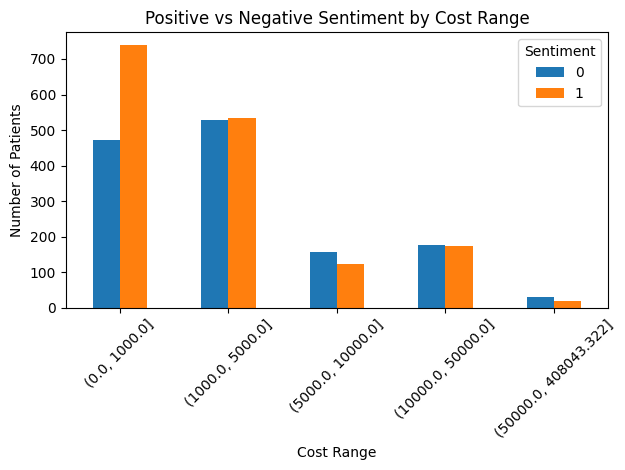

In [30]:
grouped.plot(kind="bar")

plt.xlabel("Cost Range")
plt.ylabel("Number of Patients")
plt.title("Positive vs Negative Sentiment by Cost Range")

plt.xticks(rotation=45)
plt.legend(title="Sentiment")
plt.tight_layout()

plt.show()

In [31]:
percent_positive = df_surveys_without_na.groupby("cost_bin")["sentiment_binary"].mean() * 100
print(percent_positive)

cost_bin
(0.0, 1000.0]            61.042184
(1000.0, 5000.0]         50.235183
(5000.0, 10000.0]        43.727599
(10000.0, 50000.0]       49.428571
(50000.0, 408043.322]    38.297872
Name: sentiment_binary, dtype: float64


/tmp/ipykernel_11079/481514813.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  percent_positive = df_surveys_without_na.groupby("cost_bin")["sentiment_binary"].mean() * 100


The above plot and table make it incredibly clear that the best feedback typically comes from those who spend less money, with the $0-$1000 bin having easily the highest percentage of positive feedback (at 61.04% positive feedback), whereas the highest rate of negative feedback comes from the $50,000+ bin (at 38.3% positive rate).

# Patient Search

In [32]:
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline
model_name = "Qwen/Qwen3-4B"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16,
    device_map="auto"
)

# set up generator pipeline
generator = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    device_map="auto"
)

config.json:   0%|          | 0.00/726 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

In [35]:
def build_member_profile(member_id):
    member_data = df_surveys_without_na[df_surveys_without_na["Member ID"] == member_id]

    if member_data.empty:
        return None

    row = member_data.iloc[0]

    profile = f"""
Member ID: {member_id}

Survey Responses:
{row.to_dict()}

Sentiment Score: {row.get('sentiment_score', 'N/A')}
Total Cost: {row.get('cost', 'N/A')}
"""

    return profile

def explain_member(member_id):
    profile = build_member_profile(member_id)

    if profile is None:
        return "Member not found."

    messages = [
        {
            "role": "system",
            "content": "You are a healthcare assistant building a profile on a patient. Be concise and factual."
        },
        {
            "role": "user",
            "content": f"""
Summarize this patient:

{profile}

Focus on:
- sentiment
- cost
- notable patterns
"""
        }
    ]

    prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    output = generator(
        prompt,
        max_new_tokens=200,
        temperature=0.3
    )

    return output[0]["generated_text"]